# SmartCart Day 5a - Assemble + ONNX

Time to wire the whole pipeline together - detector -> crops -> features -> head + catalog search - then **export the head to ONNX**, prove numerical parity, and quantize it for a smaller, faster model ready to deploy in tomorrow's app.

In [1]:
# 1) Runtime setup
# This course runs in Google Colab. Run this cell first.
# Install only the packages used in this notebook.
%pip install -q timm ultralytics onnx onnxruntime

import os

# Drive stores the small cross-day bundle, not the image dataset.
from google.colab import drive
drive.mount('/content/drive')
BUNDLE_DIR = '/content/drive/MyDrive/snaic/week_4/Project/SmartCart'



     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 72.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.1/19.1 MB 88.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.7/18.7 MB 74.9 MB/s eta 0:00:00
Mounted at /content/drive


### Embedded toolkit

This cell defines the helper functions used below. Run it once after setup.

In [2]:
from __future__ import annotations
import json
import os
import pathlib
import subprocess
import numpy as np
import pandas as pd
HERE = pathlib.Path.cwd()  # embedded in-notebook: no __file__, anchor on the working dir
GROCERY_DATASET_URL = 'https://github.com/marcusklasson/GroceryStoreDataset'

class Bundle:
    """Small Google Drive folder that carries artifacts from one day to the next."""

    def __init__(self, root: str):
        self.root = pathlib.Path(root)
        self.root.mkdir(parents=True, exist_ok=True)
        self.manifest = {'version': 1, 'class_list': [], 'artifacts': {}}

    def put_table(self, name, df: pd.DataFrame):
        df.to_csv(self.root / name, index=False)
        self._note(name)

    def get_table(self, name) -> pd.DataFrame:
        return pd.read_csv(self.root / name)

    def put_array(self, name, arr: np.ndarray):
        np.save(self.root / name, arr)
        self._note(name)

    def get_array(self, name) -> np.ndarray:
        p = self.root / name
        return np.load(p if p.suffix == '.npy' else p.with_suffix('.npy'))

    def _note(self, name):
        self.manifest['artifacts'][name] = True

    def save(self):
        (self.root / 'manifest.json').write_text(json.dumps(self.manifest, indent=2))

    def load(self):
        p = self.root / 'manifest.json'
        if p.exists():
            self.manifest = json.loads(p.read_text())
        return self

def open_bundle(drive_dir='/content/drive/MyDrive/SmartCart') -> Bundle:
    """Open the cross-day Drive bundle. If it is new, start with an empty manifest."""
    return Bundle(drive_dir).load()

def save_bundle(b: Bundle):
    b.save()
    print(f'[bundle] saved -> {b.root}')

def load_backbone(name='vit_small_patch14_dinov2.lvd142m', device='cpu'):
    """Frozen DINOv2-small feature extractor."""
    import timm
    m = timm.create_model(name, pretrained=True, num_classes=0, dynamic_img_size=True).eval().to(device)
    for p in m.parameters():
        p.requires_grad_(False)
    return m

def extract_features(model, batches, device=None) -> np.ndarray:
    """Run image batches through a frozen backbone and return numpy features."""
    import torch
    if device is None:
        try:
            device = next(model.parameters()).device
        except (AttributeError, StopIteration):
            device = 'cpu'
    outs = []
    with torch.no_grad():
        for xb in batches:
            y = model(xb.to(device))
            outs.append(y.detach().cpu().numpy().astype('float32'))
    return np.concatenate(outs, 0)

class EmbeddingIndex:
    """Cosine nearest-neighbor index over catalog/gallery embeddings."""

    def __init__(self):
        self._nn = None
        self.meta = []

    def build(self, feats: np.ndarray, meta: list[dict]):
        from sklearn.neighbors import NearestNeighbors
        f = feats / (np.linalg.norm(feats, axis=1, keepdims=True) + 1e-08)
        self._nn = NearestNeighbors(n_neighbors=min(10, len(f)), metric='cosine').fit(f)
        self.meta = meta
        self._feats = f
        return self

    def query(self, q: np.ndarray, k=5):
        qn = q / (np.linalg.norm(q, axis=1, keepdims=True) + 1e-08)
        dist, idx = self._nn.kneighbors(qn, n_neighbors=min(k, len(self.meta)))
        return [[{**self.meta[j], 'score': float(1 - d)} for d, j in zip(drow, irow)] for drow, irow in zip(dist, idx)]

    def save(self, b: Bundle, prefix='gallery'):
        b.put_array(f'{prefix}_index.npy', self._feats)
        b.put_table(f'{prefix}_meta.csv', pd.DataFrame(self.meta))

    @classmethod
    def load(cls, b: Bundle, prefix='gallery'):
        feats = b.get_array(f'{prefix}_index.npy')
        meta = b.get_table(f'{prefix}_meta.csv').to_dict('records')
        return cls().build(feats, meta)

class LinearHead:
    """Tiny torch linear classifier trained on frozen image features."""

    def __init__(self, in_dim, n_classes):
        import torch
        import torch.nn as nn
        self.net = nn.Linear(in_dim, n_classes)
        self.torch = torch

    def fit(self, X, y, epochs=30, lr=0.01):
        t = self.torch
        opt = t.optim.Adam(self.net.parameters(), lr=lr)
        lossf = t.nn.CrossEntropyLoss()
        Xt = t.tensor(X)
        yt = t.tensor(y)
        for _ in range(epochs):
            opt.zero_grad()
            loss = lossf(self.net(Xt), yt)
            loss.backward()
            opt.step()
        return self

    def predict(self, X):
        with self.torch.no_grad():
            return self.net(self.torch.tensor(X)).argmax(1).numpy()

def load_head(path) -> LinearHead:
    import torch
    ckpt = torch.load(path, map_location='cpu')
    head = LinearHead(ckpt['in_dim'], ckpt['n_classes'])
    head.net.load_state_dict(ckpt['state_dict'])
    head.net.eval()
    return head

def export_head_onnx(head: LinearHead, in_dim, path):
    import torch
    torch.onnx.export(head.net, torch.zeros(1, in_dim), path, input_names=['feat'], output_names=['logits'], dynamic_axes={'feat': {0: 'n'}, 'logits': {0: 'n'}}, opset_version=17, dynamo=False)
    return path

def onnx_parity(head, onnx_path, x):
    import onnxruntime as ort
    ref = head.net(head.torch.tensor(x)).detach().numpy()
    got = ort.InferenceSession(onnx_path).run(None, {'feat': x})[0]
    return float(np.abs(ref - got).max())

def basket_total(items, prices, default=0.0):
    return float(sum((prices.get(it['fine'], default) for it in items)))

def score_feat(feat, head, classes):
    """Same scoring logic as Day 3's score_image(), but for an already-embedded
    feature vector - avoids re-running the backbone since the live pipeline below
    already has the crop's embedding in memory."""
    logits = head.net(head.torch.tensor(feat)).detach().numpy()[0]
    probs = np.exp(logits - logits.max())
    probs = probs / probs.sum()
    pred_id = int(np.argmax(logits))
    return {'pred_id': pred_id, 'pred_name': classes[pred_id], 'confidence': float(probs[pred_id])}

# Confidence below this is flagged as needing manual review rather than trusted
# silently. Tune with Day 3's evaluate_confidence_thresholds() sweep before shipping;
# 0.5 is a placeholder, not a validated cutoff.
CONFIDENCE_THRESHOLD = 0.5
# --- helpers are now available as plain functions/classes in this notebook ---
print('SmartCart toolkit ready')


SmartCart toolkit ready


In [3]:
# 2) Load the cross-day bundle
# The bundle stores artifacts we create during the week: labels, indexes, weights, ONNX files.
# It is NOT the image dataset. Images are loaded in the next data-source cell.
b = open_bundle(BUNDLE_DIR)
print('bundle:', b.root)
print('artifacts:', list(b.manifest.get('artifacts', {})))


bundle: /content/drive/MyDrive/snaic/week_4/Project/SmartCart
artifacts: ['gallery_index.npy', 'gallery_meta.csv', 'catalog_prices.csv', 'labels.csv', 'sample_scene.jpg', 'detector.pt', 'crops_manifest.csv', 'head.pt', 'per_class_metrics.csv', 'error_report.md', 'head_v2.pt', 'lift_table.csv']


## Load everything

**What:** Load the best head (v2 if present), the gallery index, and the backbone.

**Why:** Day 5 consumes every artifact the week produced - this is the integration point.

**Watch for:** If head_v2.pt is absent, use head.pt from Day 3; both export the same way.

In [4]:
from pathlib import Path
import torch
# Prefer the Day 4 improved head if it exists; otherwise use the Day 3 head.
head = load_head(str(Path(b.root)/'head_v2.pt')) if (Path(b.root)/'head_v2.pt').exists() else load_head(str(Path(b.root)/'head.pt'))
idx = EmbeddingIndex.load(b)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('using device:', device)
model = load_backbone(device=device)
price_catalog = b.get_table('catalog_prices.csv')
prices = dict(zip(price_catalog.fine, price_catalog.unit_price))
currency = price_catalog.currency.iloc[0] if 'currency' in price_catalog else 'USD'
print('loaded head, gallery index, price catalog, backbone')


using device: cuda


model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

loaded head, gallery index, price catalog, backbone


## Assemble the pipeline on one counter photo

**What:** Detect products in a scene, crop them, embed, classify with the head, and look up the catalog.

**Why:** This is the end-to-end SmartCart inference path in one cell - the thing we actually ship.

**Watch for:** Uses `sample_scene.jpg` from Day 2 by default; students can switch to whole-image mode for a single product photo.

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
using image: /content/drive/MyDrive/snaic/week_4/Project/SmartCart/sample_scene.jpg
detector boxes: 1 conf: [0.8209999799728394]
Only small boxes were found. If this is a single product photo, set INPUT_MODE = "single_product".
assembled pipeline on 1 detections


,predicted_item,confidence,needs_review,unit_price,currency,similar_gallery_matches
0,Sweet-Potato,1.0,False,1.4,USD,"[Solid-Potato, Sweet-Potato, Conference]"


estimated basket total: 1.4 USD (includes best-guess price for flagged items)


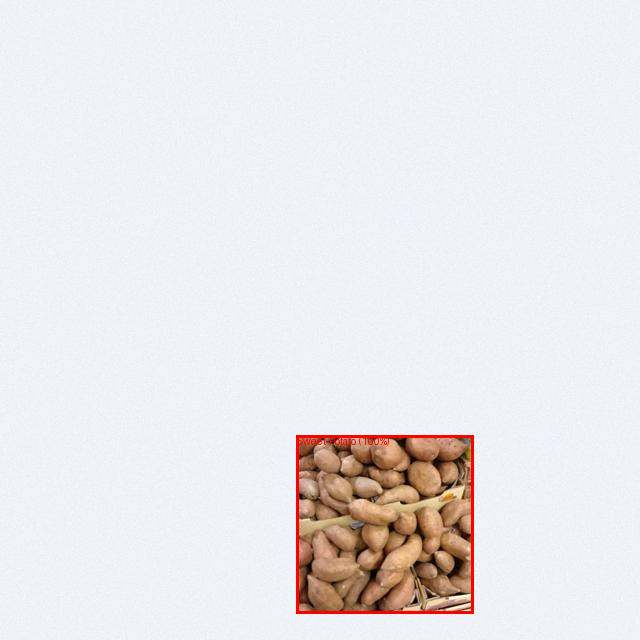

In [5]:
import torch, torchvision.transforms.v2 as T
from PIL import Image
import numpy as np
# Shared image preprocessing for DINOv2.
TF = T.Compose([T.ToImage(), T.Resize((224,224)), T.ToDtype(torch.float32, scale=True),
                T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])])
def feats_of(paths, model, bs=16):
    """Embed image files in small batches and return an (N, D) numpy array."""
    out=[]
    for i in range(0,len(paths),bs):
        xs=torch.stack([TF(Image.open(p).convert('RGB')) for p in paths[i:i+bs]])
        out.append(extract_features(model,[xs]))
    return np.concatenate(out,0)
from ultralytics import YOLO
from PIL import Image, ImageDraw
def feats_of_imgs(imgs, model):
    """Embed PIL crops already in memory."""
    xs = torch.stack([TF(im.convert('RGB')) for im in imgs])
    return extract_features(model, [xs])
classes = b.manifest.get('class_list') or sorted({m['fine'] for m in idx.meta})
det = YOLO(str(Path(b.root)/'detector.pt'))
# Choose the input style:
# - 'multi_item_scene': use YOLO boxes from a cart/counter image.
# - 'single_product': skip YOLO and classify the whole image.
# - 'auto': use YOLO, but fall back to whole image if no boxes are found.
INPUT_MODE = 'auto'
USE_UPLOAD = False  # set True in Colab to choose an image from your computer
if USE_UPLOAD:
    from google.colab import files
    uploaded = files.upload()
    assert uploaded, 'No image uploaded.'
    scene_path = next(iter(uploaded))
else:
    scene_path = str(Path(b.root)/'sample_scene.jpg')  # saved by Day 2
assert Path(scene_path).exists(), f'Image not found: {scene_path}. If using the default sample, re-run Day 2.'
print('using image:', scene_path)
img = Image.open(scene_path).convert('RGB'); arr = np.array(img)
if INPUT_MODE == 'single_product':
    print('single_product mode: skipping detector and using the whole image.')
    boxes = np.array([[0, 0, img.width, img.height]], dtype='float32')
else:
    result = det(scene_path, imgsz=640, conf=0.05, verbose=False)[0]
    boxes = result.boxes.xyxy.cpu().numpy()
    confs = result.boxes.conf.cpu().numpy() if len(result.boxes) else []
    print('detector boxes:', len(boxes), 'conf:', np.round(confs, 3).tolist())
    if len(boxes) == 0 and INPUT_MODE == 'auto':
        print('No detector boxes found; using the whole image as one product crop.')
        boxes = np.array([[0, 0, img.width, img.height]], dtype='float32')
if len(boxes):
    areas = (boxes[:,2]-boxes[:,0]) * (boxes[:,3]-boxes[:,1])
    largest = float(areas.max() / (img.width * img.height))
    if INPUT_MODE == 'auto' and largest < 0.10:
        print('Only small boxes were found. If this is a single product photo, set INPUT_MODE = "single_product".')
draw = ImageDraw.Draw(img)
# For each detected product: crop -> embed -> classify -> lookup similar catalog images + price.
# Confidence is checked here (not just predicted) - this is the one place in the whole
# pipeline that decides what the user actually sees, so it's where the "unknown item /
# confidence warning" goal from the project brief actually has to live.
rows, items = [], []
for x1,y1,x2,y2 in boxes:
    crop = Image.fromarray(arr[int(y1):int(y2), int(x1):int(x2)])
    f = feats_of_imgs([crop], model)
    s = score_feat(f, head, classes)
    pred = s['pred_name']
    needs_review = s['confidence'] < CONFIDENCE_THRESHOLD
    similar = [h['fine'] for h in idx.query(f, k=3)[0]]
    items.append({'fine': pred})
    rows.append({'predicted_item': pred, 'confidence': round(s['confidence'], 3), 'needs_review': needs_review,
                 'unit_price': prices.get(pred, 0.0), 'currency': currency, 'similar_gallery_matches': similar})
    label = f"{pred} ({s['confidence']:.0%})" + (' ?' if needs_review else '')
    box_color = 'orange' if needs_review else 'red'
    draw.rectangle([x1,y1,x2,y2], outline=box_color, width=3); draw.text((x1,y1), label, fill=box_color)
print('assembled pipeline on', len(boxes), 'detections')
display(pd.DataFrame(rows))
n_review = sum(r['needs_review'] for r in rows)
if n_review:
    print(f'⚠ {n_review} item(s) below the confidence threshold ({CONFIDENCE_THRESHOLD:.0%}) - flagged for manual review')
print('estimated basket total:', round(basket_total(items, prices, default=1.0), 2), currency, '(includes best-guess price for flagged items)')
img  # displays the annotated scene in Colab


## Export to ONNX

**What:** Export the linear head to ONNX (input 'feat', output 'logits').

**Why:** ONNX runs the classifier without PyTorch - smaller runtime, portable to many targets.

**Watch for:** YOLO exports separately via `YOLO('detector.pt').export(format='onnx')` - we focus on the head here.

In [6]:
p = export_head_onnx(head, in_dim=384, path=str(Path(b.root)/'head.onnx'))
print('exported', p)
# Detector export (run in Colab): YOLO(str(Path(b.root)/'detector.pt')).export(format='onnx')


exported /content/drive/MyDrive/snaic/week_4/Project/SmartCart/head.onnx


/tmp/ipykernel_585/2305135606.py:143: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(head.net, torch.zeros(1, in_dim), path, input_names=['feat'], output_names=['logits'], dynamic_axes={'feat': {0: 'n'}, 'logits': {0: 'n'}}, opset_version=17, dynamo=False)


## Parity check

**What:** Feed a random batch through both PyTorch and ONNX and assert they match.

**Why:** Export silently changing outputs is a classic deploy bug - we gate on it.

**Watch for:** Tolerance 1e-3 covers float rounding; a larger gap means the export is wrong.

In [7]:
x = np.random.randn(2, 384).astype('float32')
err = onnx_parity(head, p, x)
assert err < 1e-3, f'parity too loose: {err}'
print('parity', err)


parity 1.9073486328125e-06


## Quantize + benchmark

**What:** Dynamically quantize the ONNX head to int8 and time torch vs onnx vs int8.

**Why:** Quantization shrinks the model and usually speeds inference - we measure to confirm.

**Watch for:** Quantization can hit ORT edge cases; we wrap it so CI tolerates a failure with a note.

In [8]:
import time, os
sizes = {'onnx_fp32': os.path.getsize(p)}
int8_path = str(Path(b.root)/'head.int8.onnx')
try:
    from onnxruntime.quantization import quantize_dynamic, QuantType
    quantize_dynamic(p, int8_path, weight_type=QuantType.QInt8)
    sizes['onnx_int8'] = os.path.getsize(int8_path)
except Exception as e:
    print('quantization skipped:', e)
print('sizes (bytes):', sizes)
import onnxruntime as ort
sess = ort.InferenceSession(p)
xb = np.random.randn(8, 384).astype('float32')
def bench(fn, n=200):
    t0 = time.perf_counter()
    for _ in range(n): fn()
    return (time.perf_counter()-t0)/n*1e3
print('torch  ms/call:', round(bench(lambda: head.net(head.torch.tensor(xb))), 3))
print('onnx   ms/call:', round(bench(lambda: sess.run(None, {'feat': xb})), 3))
if 'onnx_int8' in sizes:
    s8 = ort.InferenceSession(int8_path)
    print('int8   ms/call:', round(bench(lambda: s8.run(None, {'feat': xb})), 3))


sizes (bytes): {'onnx_fp32': 124962, 'onnx_int8': 32342}
torch  ms/call: 0.236
onnx   ms/call: 0.092
int8   ms/call: 0.121


## Save + carry forward

**What:** Note the ONNX artifact and save the bundle.

**Why:** Day 5b loads `head.onnx` to serve predictions inside the Gradio app.

**Watch for:** Confirm head.onnx is in the bundle artifacts.

In [9]:
b._note('head.onnx')
save_bundle(b)
print('\u25b6 Carries forward to Day 5b: head.onnx')


[bundle] saved -> /content/drive/MyDrive/snaic/week_4/Project/SmartCart
▶ Carries forward to Day 5b: head.onnx
